In [1]:
import sys
from pathlib import Path

# estamos en chaos_prng/notebooks
PROJECT_ROOT = Path.cwd().resolve().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)
print("analysis exists:", (PROJECT_ROOT / "analysis").exists())


PROJECT_ROOT: C:\Users\santi\Documents\TFG\Drafts\Scripts\chaos_prng
analysis exists: True


In [2]:
%load_ext autoreload
%autoreload 2


In [3]:
import importlib
import pandas as pd
import matplotlib.pyplot as plt

import analysis.nist_sts as nist_sts
importlib.reload(nist_sts)

from analysis.nist_sts import (
    parse_all_experiments,
    experiments_to_dataframe,
)


In [4]:
NIST_RESULTS = PROJECT_ROOT / "nist_results"
print("NIST_RESULTS:", NIST_RESULTS)
print("Exists:", NIST_RESULTS.exists())


NIST_RESULTS: C:\Users\santi\Documents\TFG\Drafts\Scripts\chaos_prng\nist_results
Exists: True


In [5]:
experiments = parse_all_experiments(NIST_RESULTS)
len(experiments), [e["experiment"] for e in experiments]


(13,
 ['experiments_chacha_raw',
  'experiments_henon_raw',
  'experiments_henon_sha2',
  'experiments_henon_sha3',
  'experiments_henon_vn',
  'experiments_logistic_raw',
  'experiments_logistic_sha2',
  'experiments_logistic_sha3',
  'experiments_logistic_vn',
  'experiments_tent_raw',
  'experiments_tent_sha2',
  'experiments_tent_sha3',
  'experiments_tent_vn'])

In [6]:
df = experiments_to_dataframe(experiments)
df.head(20)


,experiment,test,p_value,passed
0,experiments_chacha_raw,Frequency,0.350485,True
1,experiments_chacha_raw,BlockFrequency,0.911413,True
2,experiments_chacha_raw,CumulativeSums,0.350485,True
3,experiments_chacha_raw,CumulativeSums,0.534146,True
4,experiments_chacha_raw,Runs,0.739918,True
5,experiments_chacha_raw,LongestRun,0.911413,True
6,experiments_chacha_raw,Rank,0.004301,True
7,experiments_chacha_raw,FFT,0.991468,True
8,experiments_chacha_raw,NonOverlappingTemplate,0.213309,True
9,experiments_chacha_raw,NonOverlappingTemplate,0.534146,True


In [7]:
summary = (
    df.groupby("experiment")
      .agg(
          tests_total=("passed", "count"),
          tests_passed=("passed", "sum"),
      )
)

summary["pass_rate"] = summary["tests_passed"] / summary["tests_total"]

summary.head(12)


,tests_total,tests_passed,pass_rate
experiment,,,
experiments_chacha_raw,188,188,1.000000
experiments_henon_raw,187,27,0.144385
experiments_henon_sha2,188,188,1.000000
experiments_henon_sha3,188,188,1.000000
experiments_henon_vn,185,27,0.145946
experiments_logistic_raw,162,2,0.012346
experiments_logistic_sha2,188,187,0.994681
experiments_logistic_sha3,188,186,0.989362
experiments_logistic_vn,188,29,0.154255


In [8]:
tmp = summary.reset_index()

tmp["generator"] = (
    tmp["experiment"]
    .str.replace("experiments_", "", regex=False)
    .str.split("_")
    .str[0]
)

tmp["variant"] = (
    tmp["experiment"]
    .str.replace("experiments_", "", regex=False)
    .str.split("_")
    .str[1]
)

tmp


,experiment,tests_total,tests_passed,pass_rate,generator,variant
0,experiments_chacha_raw,188,188,1.000000,chacha,raw
1,experiments_henon_raw,187,27,0.144385,henon,raw
2,experiments_henon_sha2,188,188,1.000000,henon,sha2
3,experiments_henon_sha3,188,188,1.000000,henon,sha3
4,experiments_henon_vn,185,27,0.145946,henon,vn
5,experiments_logistic_raw,162,2,0.012346,logistic,raw
6,experiments_logistic_sha2,188,187,0.994681,logistic,sha2
7,experiments_logistic_sha3,188,186,0.989362,logistic,sha3
8,experiments_logistic_vn,188,29,0.154255,logistic,vn
9,experiments_tent_raw,162,3,0.018519,tent,raw


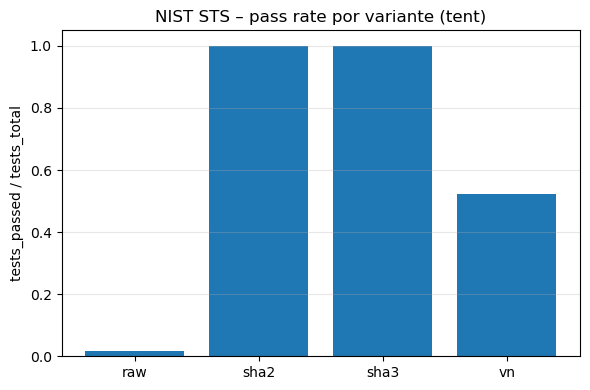

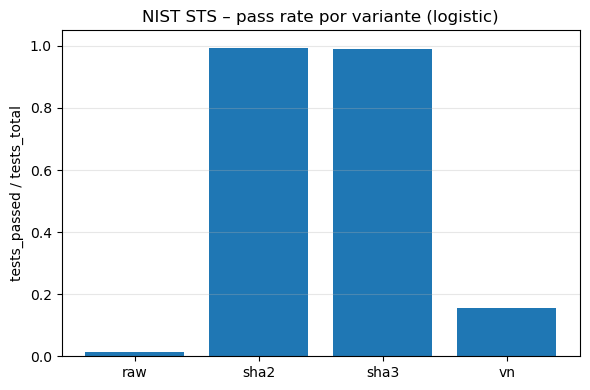

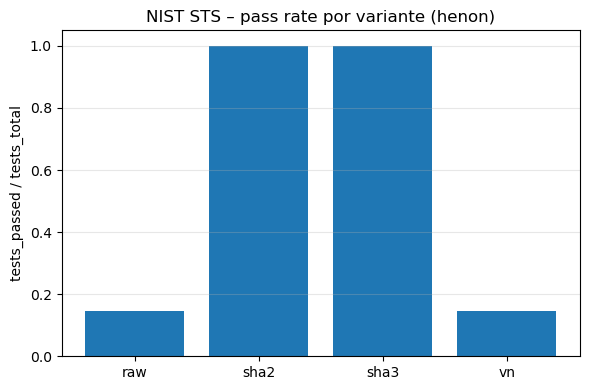

In [9]:
for gen in ["tent", "logistic", "henon"]:
    plot_df = tmp[tmp["generator"] == gen].sort_values("variant")

    plt.figure(figsize=(6, 4))
    plt.bar(plot_df["variant"], plot_df["pass_rate"])
    plt.ylim(0, 1.05)
    plt.ylabel("tests_passed / tests_total")
    plt.title(f"NIST STS – pass rate por variante ({gen})")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


In [10]:
final_table = tmp[["generator", "variant", "tests_total", "tests_passed", "pass_rate"]].copy()
final_table["pass_rate"] = final_table["pass_rate"].round(6)
final_table = final_table.sort_values(["generator", "variant"])
final_table


,generator,variant,tests_total,tests_passed,pass_rate
0,chacha,raw,188,188,1.000000
1,henon,raw,187,27,0.144385
2,henon,sha2,188,188,1.000000
3,henon,sha3,188,188,1.000000
4,henon,vn,185,27,0.145946
5,logistic,raw,162,2,0.012346
6,logistic,sha2,188,187,0.994681
7,logistic,sha3,188,186,0.989362
8,logistic,vn,188,29,0.154255
9,tent,raw,162,3,0.018519


In [11]:
order = ["raw", "sha2", "sha3", "vn"]
tmp["variant"] = pd.Categorical(tmp["variant"], categories=order, ordered=True)


In [12]:
import importlib
import analysis.nist_sts as nist_sts
importlib.reload(nist_sts)

from analysis.nist_sts import build_passrate_family_matrix


In [13]:
df_fam = df.copy()

df_fam["generator"] = (
    df_fam["experiment"]
    .str.replace("experiments_", "", regex=False)
    .str.split("_")
    .str[0]
)

df_fam["variant"] = (
    df_fam["experiment"]
    .str.replace("experiments_", "", regex=False)
    .str.split("_")
    .str[1]
)

df_fam.head()


,experiment,test,p_value,passed,generator,variant
0,experiments_chacha_raw,Frequency,0.350485,True,chacha,raw
1,experiments_chacha_raw,BlockFrequency,0.911413,True,chacha,raw
2,experiments_chacha_raw,CumulativeSums,0.350485,True,chacha,raw
3,experiments_chacha_raw,CumulativeSums,0.534146,True,chacha,raw
4,experiments_chacha_raw,Runs,0.739918,True,chacha,raw


In [14]:
M = build_passrate_family_matrix(
    df_all=df_fam,
    variant="vn",
    generators=["henon", "tent", "logistic"],
)

M


generator,henon,tent,logistic
test_family,,,
Complexity,0.333333,0.666667,0.333333
Frequency,0.750000,0.750000,0.750000
RandomWalk,0.956522,0.961538,0.923077
Runs,0.000000,0.000000,0.000000
Spectral,0.000000,1.000000,0.000000
Templates,0.000000,0.436242,0.000000


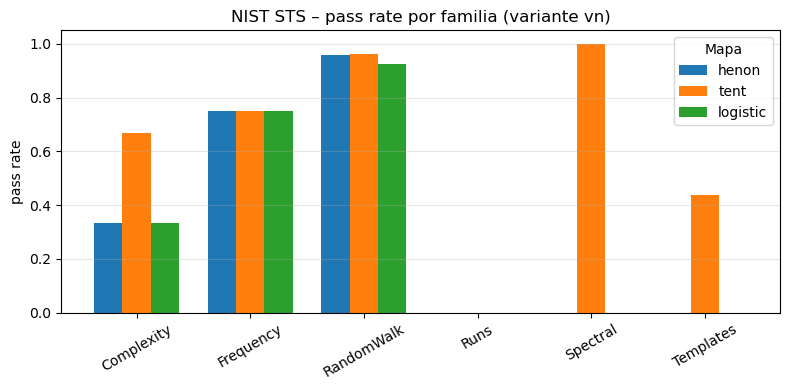

In [15]:
import numpy as np
import matplotlib.pyplot as plt

families = M.index.tolist()
generators = M.columns.tolist()

x = np.arange(len(families))
width = 0.25

plt.figure(figsize=(8, 4))

for i, gen in enumerate(generators):
    plt.bar(
        x + i * width,
        M[gen],
        width,
        label=gen,
    )

plt.xticks(x + width, families, rotation=30)
plt.ylim(0, 1.05)
plt.ylabel("pass rate")
plt.title("NIST STS – pass rate por familia (variante vn)")
plt.legend(title="Mapa")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


In [16]:
# asegúrate de tener df_fam (con generator y variant)
# y el helper build_passrate_family_matrix importado

M_sha2 = build_passrate_family_matrix(df_fam, variant="sha2", generators=["logistic"])
M_sha3 = build_passrate_family_matrix(df_fam, variant="sha3", generators=["logistic"])

# cada M tiene una columna 'logistic'; las juntamos como sha2/sha3
M_log = pd.DataFrame({
    "sha2": M_sha2["logistic"],
    "sha3": M_sha3["logistic"],
})

M_log


,sha2,sha3
test_family,,
Complexity,1.000000,1.000000
Frequency,1.000000,1.000000
RandomWalk,1.000000,1.000000
Runs,1.000000,1.000000
Spectral,1.000000,1.000000
Templates,0.993289,0.986577


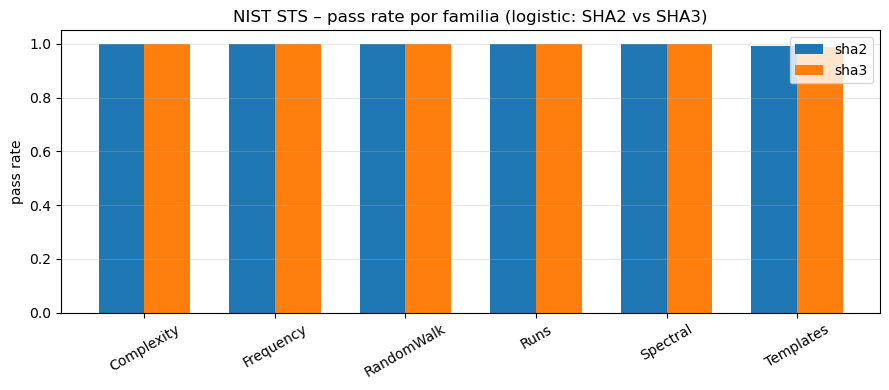

In [17]:
import numpy as np
import matplotlib.pyplot as plt

families = M_log.index.tolist()
x = np.arange(len(families))
width = 0.35

plt.figure(figsize=(9, 4))
plt.bar(x - width/2, M_log["sha2"].values, width, label="sha2")
plt.bar(x + width/2, M_log["sha3"].values, width, label="sha3")

plt.xticks(x, families, rotation=30)
plt.ylim(0, 1.05)
plt.ylabel("pass rate")
plt.title("NIST STS – pass rate por familia (logistic: SHA2 vs SHA3)")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
